In [ ]:
# Author: Eve Castonguay, LIRA (CNRS)
# Creation date: 2026-05-29 [YYYY-MM-DD]
# Version 0.1: AAAA-MM-JJ

### Making a global DataArray for each variable

In [1]:
# Imports
from datetime import datetime
import os
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import glob 
import numpy as np
import netCDF4 as nc
from scipy.spatial import KDTree

## Section 0 : Make sure the following variables are set correctly before running the code
continent_list = ['af', 'as', 'eu', 'na', 'sa', 'oc']
continent = "na" # SELECT a continent (africa: af, asia: as, europe: eu, north_america: na, south_america: sa, oceania: oc)
if continent not in continent_list:
    raise ValueError("Error: [0] Continent must be one of the following: 'af' (Africa), 'as' (Asia), 'eu' (Europe), 'na' (North America), 'sa' (South America), 'oc' (Oceania)")    
target_date_inf = "2023-08-18" # SELECT a time period for the plots
target_date_sup = "2024-09-21" # SWOT data : 2023-03-29 to 2025-05-02
use_target_date_filter = True # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available
# 0.1 Plot regarding discharge comparison
list_stations_plot = [3626000]  # SELECT stations in GRDC database to compare with SWOT data. Enter their stations id in int format.
                                # na
                                # 4127800 : article 3, fig 2a - Mississippi River near Baton Rouge, Louisiana, United States
                                # 4105850 : article 3, fig 2b - Kenai River near Soldotna, Alaska, United States
                                # eu
                                # 6139415 : article 3, fig 2c - Le Drac River near Grenoble, France
                                # sa
                                # 3626000 : amazonie, cours d'eau large de 3 km
plot_discharge_comparison = 0 # SELECT 1 to plot, 0 to ignore
# 0.2 Plot regarding all discharge data for a specific reach
selected_reach_id = 23229000561 # SELECT a reach to plot. 
                                # 74210000201 article 3, fig 2a - reach on mississippi near bâton rouge (na)
                                # 81130400011 article 3, fig 2b - the reach my code found (na)
                                # 81130400021 article 3, fig 2b - the reach they actually used (na)
                                # 21602400201 article 3, fig 2c - the reach they actually used (eu)
                                # 23229000561 article 3, fig 2d - the reach they actually used (eu)
plot_reach_discharge = 0 # SELECT 1 to plot, 0 to ignore
# 0.3 Period during which SWOT has data (2023-03-29 to 2025-05-02)
swot_start = '2023-03-29'
swot_end = '2025-05-02'
# 0.4 Empty dictionnaries for DataArrays (there probably is a better way?)
runoff_darrays_g = {} # g : grdc
geox_darrays_g = {}
geoy_darrays_g = {}
area_darrays_g = {}
dschg_darrays_s = {} # s : swot
geox_darrays_s = {}
geoy_darrays_s = {}
id_darrays_s = {}

## Section 1 : Extracting the dataset from each SWOT continent file
# This code loads the single selected continent file
dir_l4 = "/obs/ecastonguay/swot_data/L4_discharge/"
for i_continent in continent_list: # loop over continents
    file_suffix = "_sword_v16_SOS_results_unconstrained_20230502T204408_20250502T204408_20251219T163700.nc"
    single_file_name = dir_l4 + i_continent + file_suffix 
    data_l4 = nc.Dataset(single_file_name)

    ## Section 2 : Reading GRDC data
    # 2.1 Extracting the data for the continent
    dir_grdc_prefix = "/obs/ecastonguay/grdc_data/"
    file_nc = i_continent + ".nc"
    path_nc = os.path.join(dir_grdc_prefix,i_continent,file_nc)
    file_json = "stationbasins_" + i_continent + ".geojson"
    path_json = os.path.join(dir_grdc_prefix,i_continent,file_json)
    # open the netcdf grdc file
    data_grdc = xr.open_dataset(path_nc, engine="netcdf4") # <xarray.Dataset>

    # 2.2 Putting all GRDC data in DataArrays (https://docs.xarray.dev/en/stable/generated/xarray.DataArray.html) 
    # filter for the period during which SWOT has data (2023-03-29 to 2025-05-02)
    data_grdc_23_25 = data_grdc.sel(time=slice(swot_start,swot_end)) # DataSet
    # swap dimensions to have (id,time) instead of (time,id)
    data_grdc_23_25 = data_grdc_23_25.transpose()
    # 2.2.1 runoff
    runoff_darray_23_25_g = data_grdc_23_25['runoff_mean'] # DataArray  
    # 2.2.2 X coordinates in DataArray
    geox_darray_g = data_grdc_23_25.geo_x # or ['geo'] # DataArray 
    # 2.2.3 Y coordinates in DataArray
    geoy_darray_g = data_grdc_23_25.geo_y 
    # 2.2.4 Area in DataArray
    area_darray_g = data_grdc_23_25.area

    # 2.3 Get a list of the stations_id of GRDC (id is, with time, the coordinates of the DataSet)
    list_station_id = runoff_darray_23_25_g["id"].values # [tested]  

    ## Section 3 : Empty ndarrays for the SWOT data 
    station_pos = 0
    time_dim = pd.date_range(start=swot_start, end=swot_end, freq='D') # 766. ndarray-like of datetime64 data. dtype='datetime64[us]
    time_dim_len = len(time_dim)

    # 3.1 Discharge
    dschg_ndarray = np.full((len(list_station_id), time_dim_len), np.nan, dtype=np.float64) # dim (id, time)
    # 3.2 Lon
    x_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)
    # 3.3 Lat
    y_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)
    # 3.4 Reach id
    r_id_ndarray = np.full((len(list_station_id)), np.nan, dtype=np.float64) # dim (id)

    ## Section 4 : Loop for reading all the GRDC stations of the continent and associating them with a reach
    n_10nn = 0 # number of reaches that are further than the 10th nearest neighboor
    for station_id in list_station_id:
        # print("processing 1 station")
        # 4.1 Finding the target (lon,lat) and the list of coordinates from SWOT
        # get grdc (lat,lon) target coordinates (gauge)
        x_found_station = geox_darray_g.sel(id=station_id).values
        y_found_station = geoy_darray_g.sel(id=station_id).values # [tested]
        # list of reaches in the continent-level swot data 
        reach_group = data_l4.groups['reaches']
        x_coordinates_values = reach_group['x'][:] # all x coordinates in swot/l4 data for the na continent
        y_coordinates_values = reach_group['y'][:]
        # 4.2 Finding a match between the GRDC gauge and the SWOT data at reach level
        # K-D tree to search nearest neighbor (looking for the reach with the closest coordinates to the station) (consensus_q only available at reach-level)
        stacked_xy = np.vstack((x_coordinates_values,y_coordinates_values)).T
        k_neighbors = 10
        distance_list, index_list = KDTree(stacked_xy).query([x_found_station, y_found_station],k=k_neighbors) # we take the k nearest neighboors so that if the nearest reach doesn't contain swot data, we look at the second nearest, ...
        ii = 0
        no_r_found = False
        while ii < k_neighbors:
            distance = distance_list[ii]
            index = index_list[ii] # index of the reach we will be associating with the station
            # 4.3 Checking if the selected nearest reach contains data; if not, will move on to the next nearest reach
            discharge_data_check = data_l4.groups["consensus"]['consensus_q'][index] # [tested]  <class 'numpy.ndarray'>
            mask_fill_values = (discharge_data_check != data_l4.groups["consensus"]['consensus_q'].missing_value) # [tested]
            consensus_q_flt = discharge_data_check[mask_fill_values] # for a given index, is all discharge data missing value?
            if consensus_q_flt.size == 0:
                if ii == 9:
                    # print(f"Warning: [4.2] The closest reach to station {station_id} that contains data is further than the 10th nearest neighboor.")
                    n_10nn += 1
                    no_r_found = True
                ii += 1
                # print("Warning: [4.3] The closest reach doesn't contain valid data. Moving on to the next closest reach.")
                continue
            if (distance > 4):      # even if the closest reach is far, KDTree will still find a match. therefore we need to make sure the distance found isn't too big
                                    # for reference, a 5,4 km distance between reach and gauge equals to a distance = 0.0557
                                    # ADJUST maximum distance
                print(f"Warning: [4.3] The nearest reach associated with the station {station_id} is quite far from it's location. This might have an impact on the quality of the comparison.")
            # selected reach's index
            sel_r_index = index
            break # while ii < k_neighbors:
        
        if no_r_found:
            station_pos += 1 # end of the (for station_id in list_station_id:) loop
            continue # moving on to the next station, there was no reach found for this station_id. data will stay NaN.
        else: 
            ## Section 5 : Extracting relevant SWOT data and filtering out the fill values
            # 5.1 Discharge data
            # already filtered: consensus_q_flt
            # 5.2 Time data
            time_data = data_l4.groups["consensus"]['time_int'][sel_r_index]
            time_flt = time_data[mask_fill_values]
            # converting time from int to datetime
            epoch = np.datetime64('2000-01-01')
            datetime_flt = epoch + time_flt.astype('timedelta64[s]')
            # 5.3 Coordinates
            sel_r_x = data_l4.groups["reaches"]['x'][sel_r_index]
            sel_r_y = data_l4.groups["reaches"]['y'][sel_r_index]
            # 5.4 Reach's id 
            sel_r_id = data_l4.groups['reaches']['reach_id'][sel_r_index]

            ## Section 6 : Use of .get_indexer to fill the empty ndarrays with SWOT data 
            # 6.1 Put hours,min,sec to 00:00:00 to ignore time and only keep date
            datetime_norm = pd.to_datetime(datetime_flt).normalize()
            ndarray_swot_index = time_dim.get_indexer(datetime_norm) 
            if -1 in ndarray_swot_index:
                print("Error: [6.1] Not all dates from the SWOT data were found in the time_dim vector (.get_indexer method)") 
            # 6.2 SWOT discharge
            dschg_ndarray[station_pos,ndarray_swot_index] = consensus_q_flt # [tested] where there is data the space will be filled, otherwise stays NaN
            # 6.3 SWOT coordinates
            x_ndarray[station_pos] = sel_r_x
            y_ndarray[station_pos] = sel_r_y
            # 6.4 SWOT reach id
            r_id_ndarray[station_pos] = sel_r_id

        # end of the (for station_id in list_station_id:) loop
        station_pos += 1

    print(f"The number of reaches that are further than the 10th nearest neighboor of a given station is {n_10nn} for the {i_continent} continent. Currently these will be filled with NaN values.")

    ## Section 7 : Create DataArrays with SWOT (ndarrays ordered by station_id)
    # 7.1 Discharge
    dschg_darray_s = xr.DataArray(
        data=dschg_ndarray,
        dims=["id","time"], # name of the dimensions
        coords=dict(
            id=list_station_id,
            time=time_dim,
        ),
        attrs=dict(
            description="Consensus_q from SWOT",
            units="m3/s",
        ),
        name="swot discharge"
    )
    # 7.2 Coordinates
    if len(x_ndarray) != len(y_ndarray):
        print(f"Error: [7.2] The x and y vector of all the selected reaches' coordinates doesn't match in size")
        #break # *** activate when continent loop is added!
    # x_y_ndarray = np.hstack((x_ndarray,y_ndarray)) # doesn't work for now
    # dataarrays
    geox_darray_s = xr.DataArray(
        data=x_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="X coordinate of each selected reach in the SWOT data",
            units="degrees",
        ),
        name="swot x coordinate"
    )
    geoy_darray_s = xr.DataArray(
        data=y_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="Y coordinate of each selected reach in the SWOT data",
            units="degrees",
        ),
        name="swot y coordinate"
    )
    # 7.3 Reach ids
    id_darray_s = xr.DataArray(
        data=r_id_ndarray,
        dims=["id"], # name of the dimensions
        coords=dict(
            id=list_station_id,
        ),
        attrs=dict(
            description="Id's of the selected reaches in the SWOT data"
        ),
        name="swot reach ids"
    )

    ## Section 8 : Make sure all GRDC DataArrays have time dim of 766 days (between 2023-03-29 & 2025-05-02)
    # 8.1 Validate size of time dimension and possible expand
    if len(data_grdc_23_25.time) != len(runoff_darray_23_25_g.time):
        print(f"Error: [8.1] Both arrays are assumed to match in size. Please verify the code.")
    if len(runoff_darray_23_25_g.time) != time_dim_len:
        data_grdc_23_25 = data_grdc_23_25.reindex(time=time_dim) # asia doesn't -> fill the time between 2024 & 2025 with NaN
    # *** missing values seem to be nan [tested]

    ## Section 9 : Append continent DataArrays to list
    runoff_darrays_g[i_continent] = runoff_darray_23_25_g
    geox_darrays_g[i_continent] = geox_darray_g

    geoy_darrays_g[i_continent] = geoy_darray_g
    area_darrays_g[i_continent] = area_darray_g
    dschg_darrays_s[i_continent] = dschg_darray_s
    geox_darrays_s[i_continent] = geox_darray_s
    geoy_darrays_s[i_continent] = geoy_darray_s
    id_darrays_s[i_continent] = id_darray_s

# end of the (for i_continent in continent_list) loop 

## Section 10 : Concathenate continent DataArrays. These are individual DataArrays that contain values for all continents
# grdc
runoff_global_g = xr.concat(list(runoff_darrays_g.values()), dim='id') 
geox_global_g = xr.concat(list(geox_darrays_g.values()), dim='id')
geoy_global_g = xr.concat(list(geoy_darrays_g.values()), dim='id')
area_global_g = xr.concat(list(area_darrays_g.values()), dim='id')
# swot
dschg_global_s = xr.concat(list(dschg_darrays_s.values()), dim='id') 
geox_global_s = xr.concat(list(geox_darrays_s.values()), dim='id')
geoy_global_s = xr.concat(list(geoy_darrays_s.values()), dim='id')
id_global_s = xr.concat(list(id_darrays_s.values()), dim='id')

The number of reaches that are further than the 10th nearest neighboor of a given station is 23 for the af continent. Currently these will be filled with NaN values.
The number of reaches that are further than the 10th nearest neighboor of a given station is 13 for the as continent. Currently these will be filled with NaN values.
The number of reaches that are further than the 10th nearest neighboor of a given station is 466 for the eu continent. Currently these will be filled with NaN values.
The number of reaches that are further than the 10th nearest neighboor of a given station is 207 for the na continent. Currently these will be filled with NaN values.
The number of reaches that are further than the 10th nearest neighboor of a given station is 43 for the sa continent. Currently these will be filled with NaN values.
The number of reaches that are further than the 10th nearest neighboor of a given station is 164 for the oc continent. Currently these will be filled with NaN values.


/tmp/ipykernel_47406/2380419889.py:262: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  runoff_global_g = xr.concat(list(runoff_darrays_g.values()), dim='id')


### Making the DataSet

In [ ]:
dset_global = runoff_global_g.to_dataset(name='runoff_global_g')
dset_global['geox_global_g'] = geox_global_g
dset_global['geoy_global_g'] = geoy_global_g
dset_global['area_global_g'] = area_global_g
dset_global['dschg_global_s'] = dschg_global_s
dset_global['geox_global_s'] = geox_global_s
dset_global['geoy_global_s'] = geoy_global_s
dset_global['id_global_s'] = id_global_s

# change the data type of the reaches id which is (int)
dset_global["id_global_s"] = dset_global["id_global_s"].astype(int)

print(dset_global)

<xarray.Dataset> Size: 48MB
Dimensions:          (time: 766, id: 5241)
Coordinates:
  * time             (time) datetime64[us] 6kB 2023-03-29 ... 2025-05-02
  * id               (id) int64 42kB 1159100 1159103 1159110 ... 5870600 5870655
Data variables:
    runoff_global_g  (id, time) float32 16MB 433.0 424.6 414.8 ... 59.33 49.56
    geox_global_g    (id) float32 21kB 17.72 19.15 20.36 ... 171.9 171.7 172.4
    geoy_global_g    (id) float32 21kB -28.76 -28.96 -31.81 ... -41.83 -41.76
    area_global_g    (id) float32 21kB 8.665e+05 8.599e+05 ... 6.35e+03 1.41e+03
    dschg_global_s   (id, time) float64 32MB nan nan nan nan ... nan nan nan nan
    geox_global_s    (id) float64 42kB 17.76 19.14 19.48 ... 171.7 171.6 172.9
    geoy_global_s    (id) float64 42kB -28.75 -28.96 -32.13 ... -42.29 -41.83
    id_global_s      (id) int64 42kB 12730300031 12730700131 ... 57205200091


/obs/ecastonguay/miniconda3/envs/swot-env/lib/python3.14/site-packages/xarray/core/duck_array_ops.py:250: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


### Plot comparison of in-situ with grdc 

True
Figure of station 3626000 saved in /obs/ecastonguay/scripts/figures


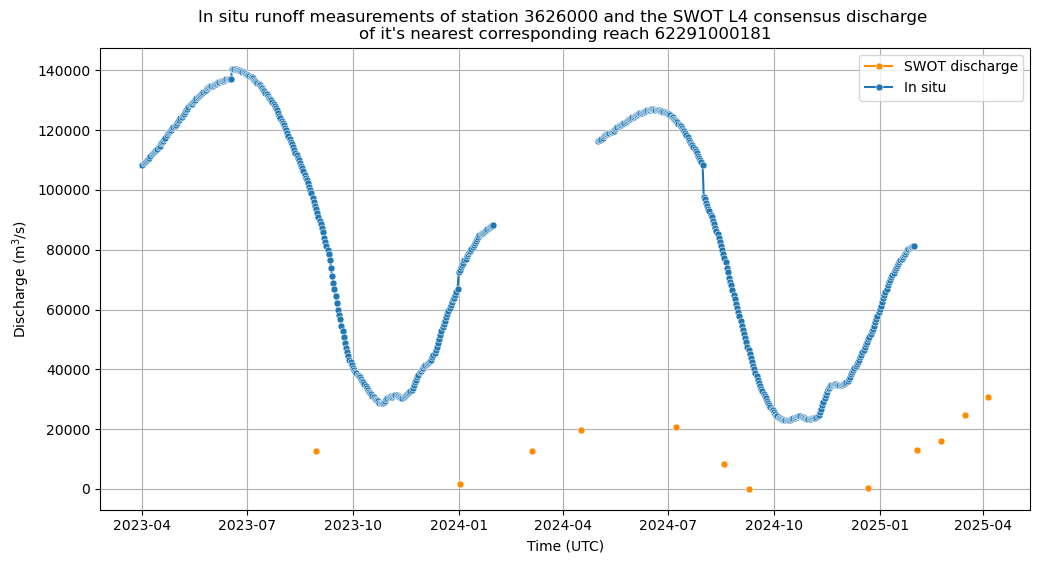

In [ ]:
# Make sure the following variables are set correctly before running the code
list_stations_plot = [3626000]  # SELECT stations in GRDC database to compare with SWOT data. Enter their stations id in int format.
                                # na
                                # 4127800 : article 3, fig 2a - Mississippi River near Baton Rouge, Louisiana, United States
                                # 4105850 : article 3, fig 2b - Kenai River near Soldotna, Alaska, United States
                                # eu
                                # 6139415 : article 3, fig 2c - Le Drac River near Grenoble, France
                                # sa
                                # 3626000 : amazonie, cours d'eau large de 3 km
target_date_inf = "2023-04-01" # SELECT a time period for the plots
target_date_sup = "2025-04-01" # SWOT data : 2023-03-29 to 2025-05-02
use_target_date_filter = True # SELECT True if we want to use the above specified target dates, False if the goal is to display the discharge data for all time period available

# Making the plots          
for station_id in list_stations_plot:
    if station_id in dset_global['id'].values:
        if use_target_date_filter: 
            # slicing data for the right id & time period
            target_datetime_inf = np.datetime64(target_date_inf, 'D')
            target_datetime_sup = np.datetime64(target_date_sup, 'D')
            dset_global_id_flt = dset_global.sel(id=station_id)
            dset_global_date_flt = dset_global_id_flt.sel(time=slice(target_date_inf,target_date_sup)) 
            closest_reach_id = dset_global_id_flt['id_global_s'].values
            
            plt.figure(figsize=(12, 6))
            plt.plot(dset_global_date_flt['time'].values,dset_global_date_flt['dschg_global_s'].values, marker='o', markersize=5, label='SWOT discharge', color='darkorange', markeredgecolor='white', markeredgewidth=0.4)
            print(dset_global_date_flt['dschg_global_s'].values)
            plt.plot(dset_global_date_flt['time'].values, dset_global_date_flt['runoff_global_g'].values, marker='o', markersize=5, label='In situ', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)

            plt.title(f"In situ runoff measurements of station {station_id} and the SWOT L4 consensus discharge \nof it's nearest corresponding reach {closest_reach_id}") 
            plt.xlabel('Time (UTC)') 
            plt.ylabel(r'Discharge (m$^3$/s)')

            plt.legend()
            plt.grid(True)
        else:
            # slicing data for the right id 
            dset_global_id_flt = dset_global.sel(id=station_id)
            closest_reach_id = dset_global_id_flt['id_global_s'].values

            plt.figure(figsize=(12, 6))
            plt.plot(dset_global_id_flt['time'].values,dset_global_id_flt['dschg_global_s'].values, marker='o', markersize=5, label='SWOT discharge', color='darkorange', markeredgecolor='white', markeredgewidth=0.4)
            plt.plot(dset_global_id_flt['time'].values, dset_global_id_flt['runoff_global_g'].values, marker='o', markersize=5, label='In situ', color='tab:blue', alpha=1, markeredgecolor='white', markeredgewidth=0.4)

            plt.title(f"In situ runoff measurements of station {station_id} and the SWOT L4 consensus discharge \nof it's nearest corresponding reach {closest_reach_id}") 
            plt.xlabel('Time (UTC)') 
            plt.ylabel(r'Discharge (m$^3$/s)')

            plt.legend()
            plt.grid(True)

        if use_target_date_filter:
            fig_name = f'TEST DSET discharge_comparison_station{station_id}_r{closest_reach_id}_{target_date_inf}_{target_date_sup}.png' # SELECT file name
        else:
            fig_name = f'TEST DSET discharge_comparison_station{station_id}_r{closest_reach_id}.png' # SELECT file name
        
        # save figure
        plt.savefig(f'/obs/ecastonguay/scripts/figures/{fig_name}', dpi=400, bbox_inches='tight')
        print(f"Figure of station {station_id} saved in /obs/ecastonguay/scripts/figures") # *** currently no error message if one of the station required to be plotted isn't in the GRDC data -> print(f"There is no correspondence in the GRDC in situ files for station id {station_id}")
        plt.show()  
    else:
        print(f'Error: the station {station_id} is not in the list of station ids from the GRDC data')
